<a href="https://colab.research.google.com/github/arahmantantawy/MachineLearning/blob/main/AbdLab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library imports



In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import category_encoders as ce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skewnorm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
sns.set_style('whitegrid')


In [ ]:
# import importlib
# import matplotlib as mpl
# importlib.reload(mpl); importlib.reload(plt); importlib.reload(sns)

In [ ]:
# Downloaded from UCI Machine learning repository
# https://archive.ics.uci.edu/ml/datasets/iris
# "Data Folder" -> iris.data
# "Data Folder" -> iris.names will give us some more data on the attributes

df_iris = pd.read_csv('iris.csv',
                        names=['SepalLength','SepalWidth','PetalLength','PetalWidth','Species'])


In [ ]:
#df = pd.read_csv(/content/iris.csv)
df_iris.head(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,Type,PW,PL,SW,SL
1,0,2,14,33,50
2,1,24,56,31,67
3,1,23,51,31,69
4,0,2,10,36,46
5,1,20,52,30,65
6,1,19,51,27,58
7,2,13,45,28,57
8,2,16,47,33,63
9,1,17,45,25,49


In [ ]:
df_iris.tail(10)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
141,1,22,58,30,65
142,0,3,14,35,51
143,2,14,47,29,61
144,1,19,53,27,64
145,0,2,16,34,48
146,1,20,50,25,57
147,2,13,40,23,55
148,0,2,17,34,54
149,1,24,51,28,58
150,0,2,15,37,53


In [ ]:
#how big the data is:

df_iris.shape

(151, 5)

In [ ]:
X = df_iris.drop(columns = 'Species')

In [ ]:
X

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,Type,PW,PL,SW
1,0,2,14,33
2,1,24,56,31
3,1,23,51,31
4,0,2,10,36
...,...,...,...,...
146,1,20,50,25
147,2,13,40,23
148,0,2,17,34
149,1,24,51,28


In [ ]:
y = df_iris['Species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
df_iris_test = X_test
df_iris_test['Species'] = y_test
df_iris_test.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
76,2,13,42,26,57
18,0,2,16,38,51
82,2,16,45,34,60
81,0,4,17,39,54
143,2,14,47,29,61


In [ ]:
df_iris_train = X_train
df_iris_train["Species"] = y_train
df_iris_train.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
105,1,18,55,30,65
4,0,2,10,36,46
32,2,14,39,27,52
42,1,21,54,31,69
144,1,19,53,27,64


In [ ]:
df_iris_train.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
count,113,113,113,113,113
unique,4,22,40,21,32
top,2,2,15,30,63
freq,39,21,10,20,7


In [ ]:
df_iris_train.describe(include='all')

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
count,113,113,113,113,113
unique,4,22,40,21,32
top,2,2,15,30,63
freq,39,21,10,20,7


In [ ]:
df_iris_train.columns

Index(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species'], dtype='object')

<Axes: xlabel='PetalLength', ylabel='Species'>

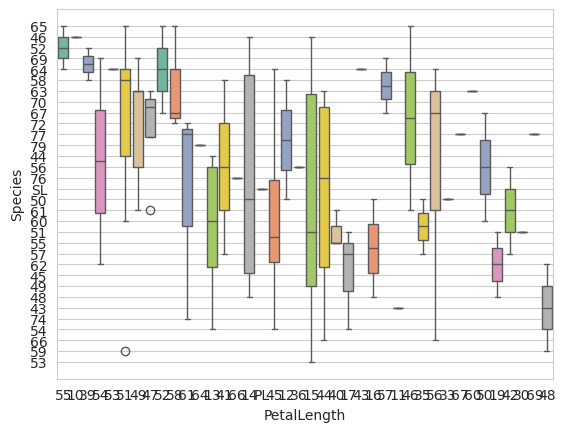

In [ ]:
import warnings  # stop the warnings
warnings.filterwarnings('ignore')
sns.boxplot(data = df_iris_train, x = df_iris_train["PetalLength"], y=df_iris_train["Species"], palette="Set2")

<Axes: xlabel='PetalWidth', ylabel='Species'>

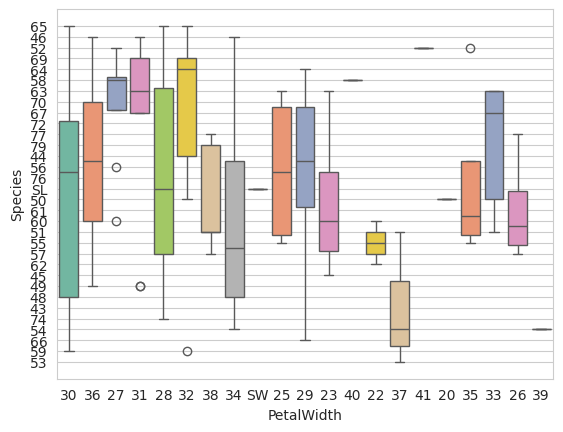

In [ ]:
sns.boxplot(data = df_iris_train, x = df_iris_train["PetalWidth"], y=df_iris_train["Species"],palette="Set2")


ValueError: The palette dictionary is missing keys: {'74', '69', '45', '52', '76', '60', '55', '50', '72', '53', '49', '46', '65', '56', '43', '70', '61', '64', '57', '66', '59', '51', '54', '77', '62', '44', '67', '58', '79', '63', 'SL', '48'}

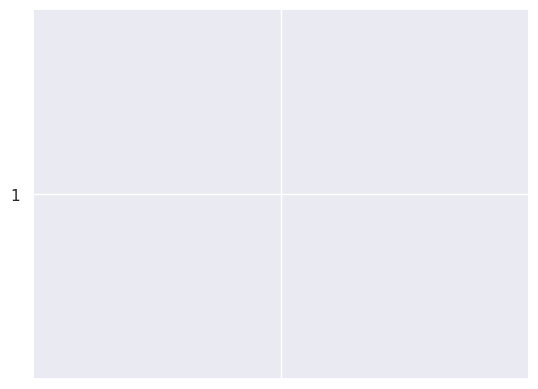

In [ ]:
sns.set_theme(style="darkgrid")


my_pal = {"Iris-virginica": "g", "Iris-versicolor": "b", "Iris-setosa":"m"}
sns.boxplot(hue=df_iris_train["Species"], y=df_iris_train["SepalLength"], palette=my_pal)
plt.show()

<Axes: xlabel='SepalWidth', ylabel='Species'>

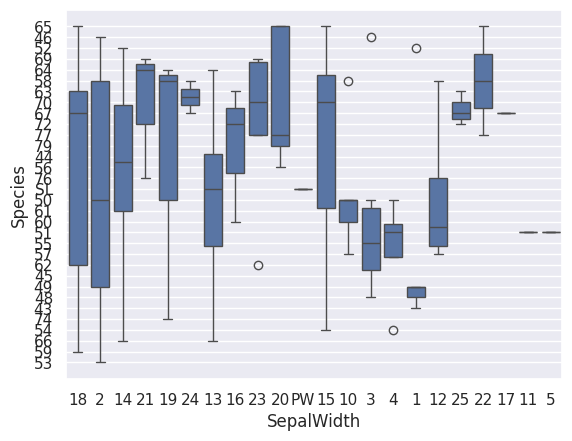

In [ ]:
sns.boxplot(data = df_iris_train, x = df_iris_train["SepalWidth"], y=df_iris_train["Species"])

<Axes: xlabel='SepalLength', ylabel='SepalWidth'>

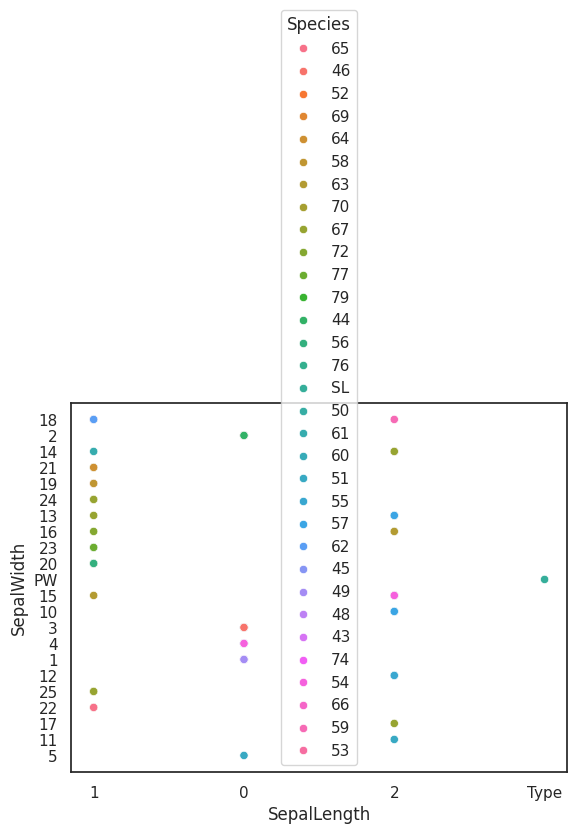

In [ ]:
sns.set_theme(style="white")
sns.scatterplot(x='SepalLength', y='SepalWidth',
                hue='Species', data=df_iris_train)

<Axes: xlabel='PetalLength', ylabel='PetalWidth'>

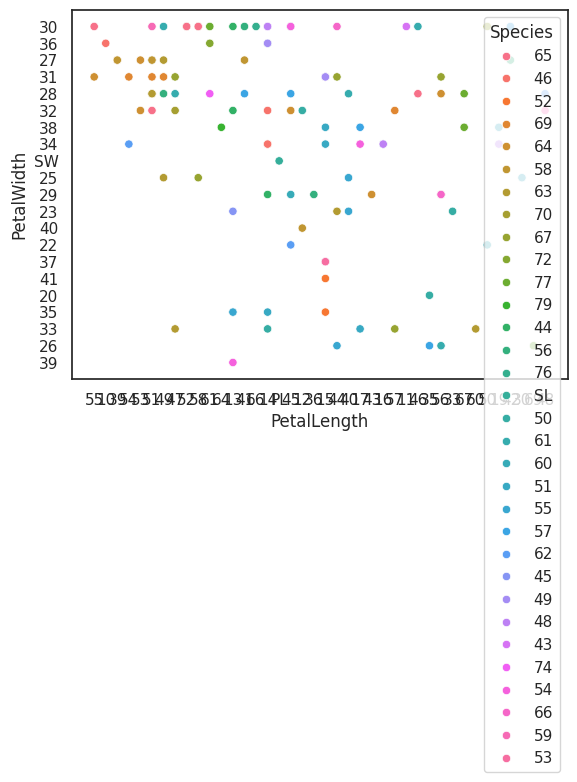

In [ ]:
sns.scatterplot(x='PetalLength', y='PetalWidth',
                hue='Species', data=df_iris_train)

In [ ]:
sns.pairplot(df_iris_train,
             hue='Species', height=2)

ValueError: No variables found for grid columns.

In [ ]:

df_iris_corr = df_iris_train.corr(method='pearson', numeric_only=True)
df_iris_corr

""


In [ ]:

sns.heatmap(df_iris_corr, annot=True)

In [ ]:
df_iris.isnull().sum()

,0
SepalLength,0
SepalWidth,0
PetalLength,0
PetalWidth,0
Species,0


In [ ]:
df_iris

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,Type,PW,PL,SW,SL
1,0,2,14,33,50
2,1,24,56,31,67
3,1,23,51,31,69
4,0,2,10,36,46
...,...,...,...,...,...
146,1,20,50,25,57
147,2,13,40,23,55
148,0,2,17,34,54
149,1,24,51,28,58


In [ ]:
df_iris["Species"].unique()

array(['SL', '50', '67', '69', '46', '65', '58', '57', '63', '49', '70',
       '48', '44', '51', '64', '60', '54', '55', '52', '59', '56', '72',
       '68', '66', '62', '61', '47', '43', '77', '45', '76', '79', '71',
       '74', '73', '53'], dtype=object)

In [ ]:
#

def encode_and_bind(original_dataframe, feature_to_encode):
    dummies = pd.get_dummies(original_dataframe[[feature_to_encode]],dtype=int)
    newEncodedData = pd.concat([original_dataframe, dummies], axis=1)

    original_dataframe = newEncodedData.drop([feature_to_encode], axis=1)

    return( original_dataframe)

In [ ]:
feature_to_encode = 'Species'

encoded_data = encode_and_bind(df_iris, feature_to_encode)

In [ ]:
encoded_data.tail(5)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species_43,Species_44,Species_45,Species_46,Species_47,Species_48,...,Species_69,Species_70,Species_71,Species_72,Species_73,Species_74,Species_76,Species_77,Species_79,Species_SL
146,1,20,50,25,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
147,2,13,40,23,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
148,0,2,17,34,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
149,1,24,51,28,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150,0,2,15,37,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_iris[df_iris.duplicated()]

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
26,1,19,51,27,58


## Drop duplicates



In [ ]:
df.drop_duplicates

In [ ]:

df_iris["Species"].value_counts()

,count
Species,
50,9
63,9
51,9
67,8
57,8
55,7
64,7
58,7
54,6


<Axes: xlabel='Species', ylabel='count'>

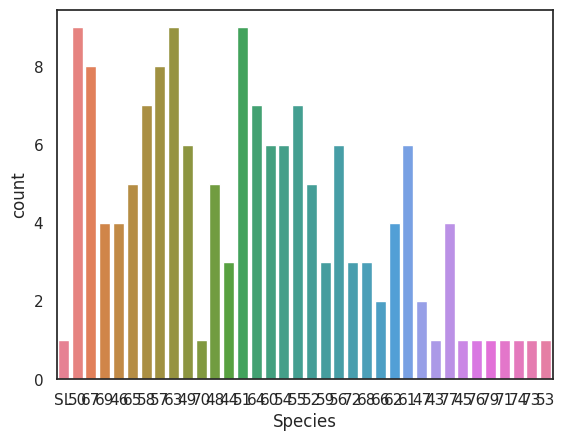

In [ ]:
sns.countplot(data = df_iris, x ="Species", hue="Species")

In [ ]:
df_iris_train["Species"].value_counts()

,count
Species,
63,7
67,7
51,7
50,7
64,6
58,5
56,5
65,5
57,5


<Axes: xlabel='Species', ylabel='count'>

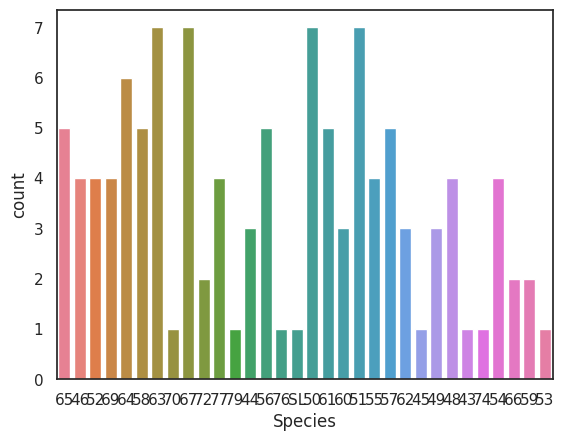

In [ ]:
sns.countplot(data = df_iris_train, x = "Species", hue="Species")

# Linear Regression

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
df.shape

(200, 4)

In [ ]:
train_df.shape

(160, 4)

In [ ]:
test_df.shape

(40, 4)

In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


(array([[ 26.,  14.,  22.,  18.,  19.,  17.,  22.,  26.,  20.,  16.],
        [129.,  71.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [108.,  72.,  17.,   3.,   0.,   0.,   0.,   0.,   0.,   0.],
        [200.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]]),
 array([  0.  ,  29.64,  59.28,  88.92, 118.56, 148.2 , 177.84, 207.48,
        237.12, 266.76, 296.4 ]),
 <a list of 4 BarContainer objects>)

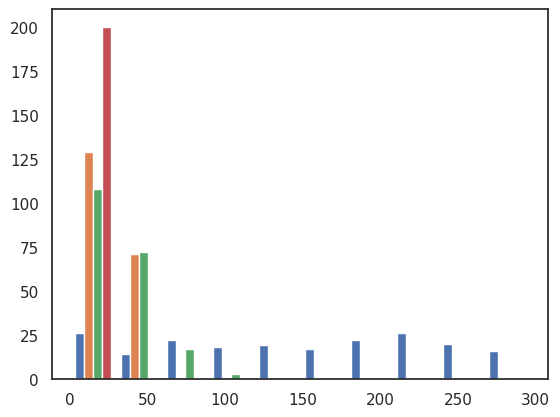

In [ ]:
plt.hist(df)

<Axes: xlabel='TV', ylabel='Count'>

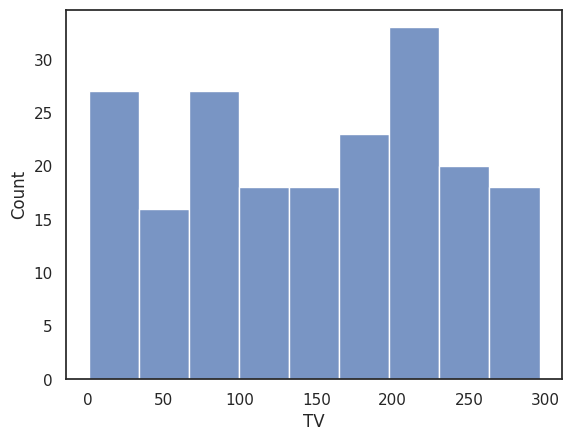

In [ ]:
sns.histplot(df.TV)

<Axes: >

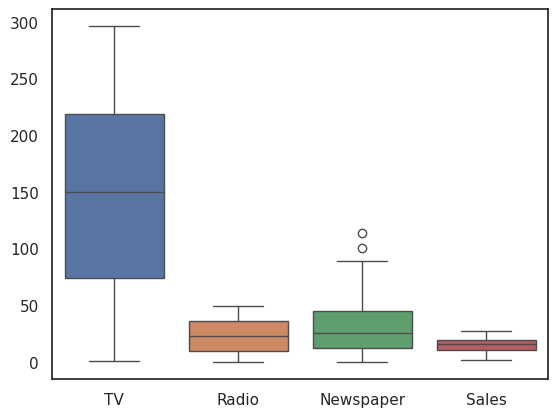

In [ ]:
sns.boxplot(df)

<Axes: xlabel='TV', ylabel='Sales'>

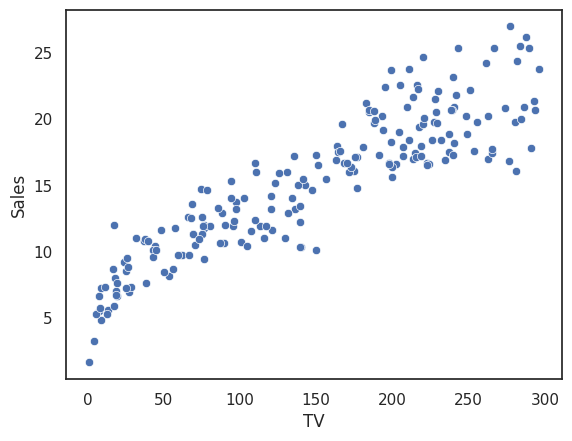

In [ ]:
sns.scatterplot(x=df.TV, y=df.Sales)

In [ ]:
sns.heatmap()

TypeError: heatmap() missing 1 required positional argument: 'data'

## Simple Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

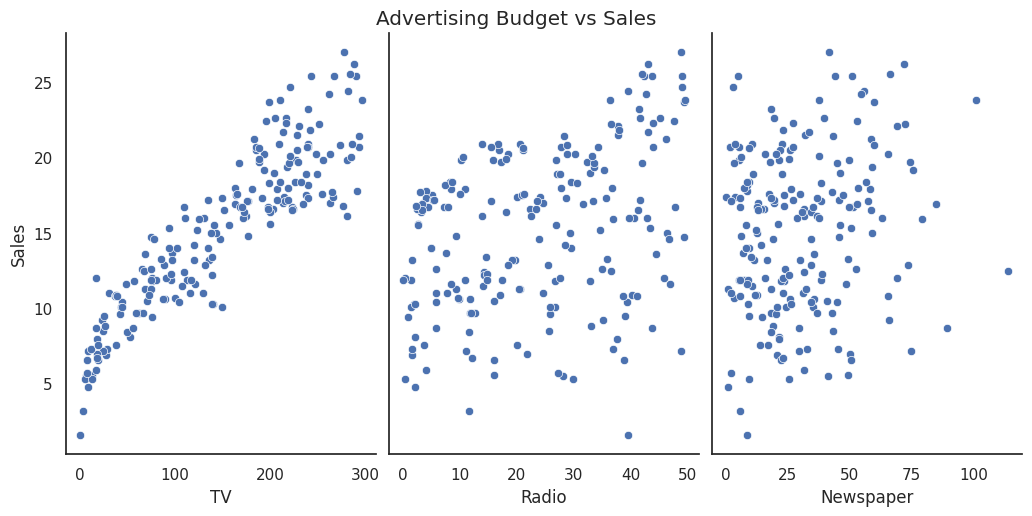

In [ ]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.7, kind='scatter')
plt.suptitle('Advertising Budget vs Sales', y=1.02)
plt.show()

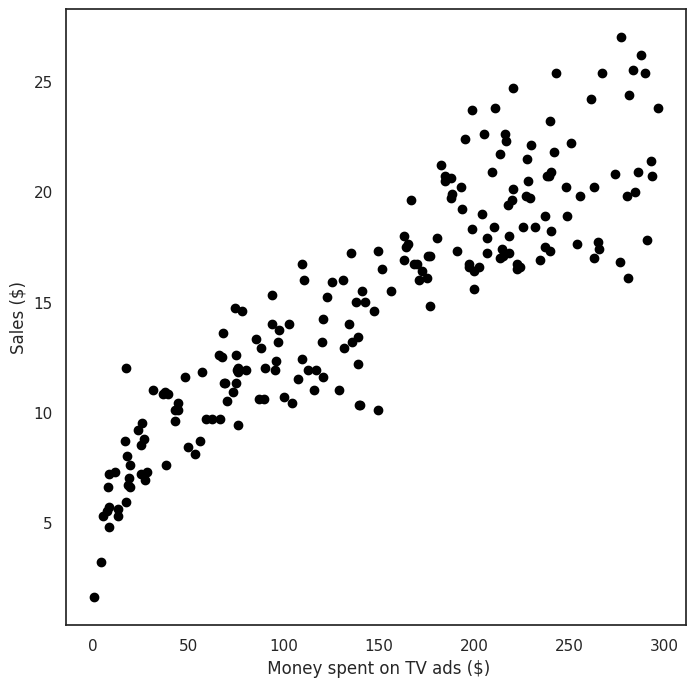

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(df['TV'], df['Sales'], c = 'black')
plt.xlabel(' Money spent on TV ads ($)')
plt.ylabel('Sales ($)')

plt.show()

In [ ]:
# X = data['TV'].values.reshape(-1,1)
# y = data['sales'].values.reshape(-1,1)

In [ ]:
# Splitting the data into training and testing sets
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Initializing the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")


Model Evaluation Metrics:
Mean Squared Error (MSE): 2.54
Root Mean Squared Error (RMSE): 1.59
R-squared (R2 Score): 0.91


In [ ]:
# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Regressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R2 Score): {r2_dt:.2f}")



Decision Tree Regressor Evaluation Metrics:
Mean Squared Error (MSE): 3.06
Root Mean Squared Error (RMSE): 1.75
R-squared (R2 Score): 0.89


In [ ]:
# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2 Score): {r2_rf:.2f}")


Random Forest Regressor Evaluation Metrics:
Mean Squared Error (MSE): 1.67
Root Mean Squared Error (RMSE): 1.29
R-squared (R2 Score): 0.94


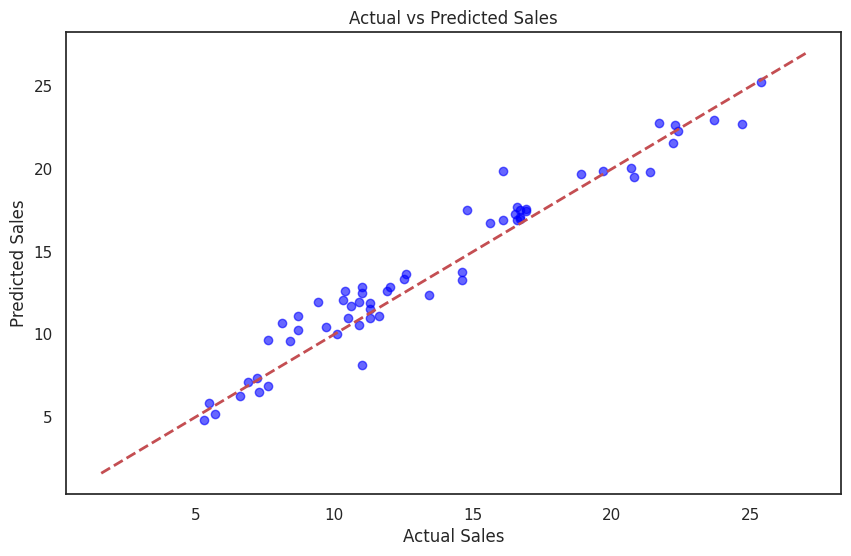

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

In [ ]:
model.intercept_

In [ ]:
model.coef_

In [ ]:
df = pd.read_csv("car_price.csv")

In [ ]:
df.columns

Index(['ID', 'symboling', 'name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [ ]:
df['name_volkswagen type 3'].value_counts()

,count
name_volkswagen type 3,
False,204
True,1


In [ ]:
df.head(10)

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


In [ ]:
df['fueltypes'].value_counts()

,count
fueltypes,
gas,185
diesel,20


In [ ]:
df['name'].value_counts()

,count
name,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [ ]:
df.shape

(205, 26)

In [ ]:
df.describe()

,ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


<Axes: xlabel='price', ylabel='horsepower'>

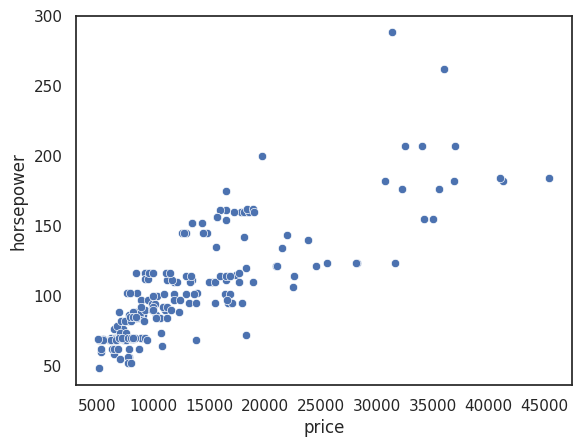

In [ ]:
sns.scatterplot(x=df.price, y=df.horsepower)

<Axes: xlabel='price', ylabel='enginesize'>

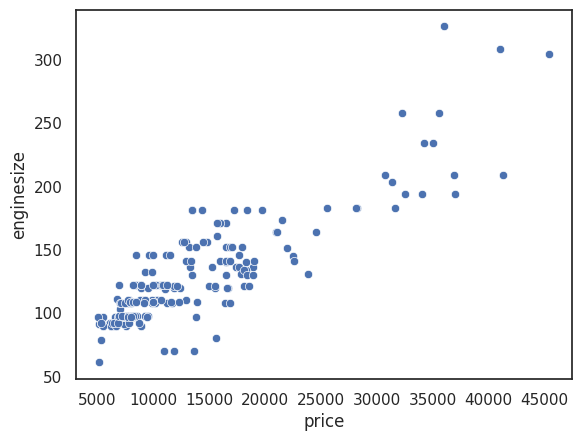

In [ ]:
sns.scatterplot(x=df.price, y=df.enginesize)

<Axes: xlabel='price', ylabel='Count'>

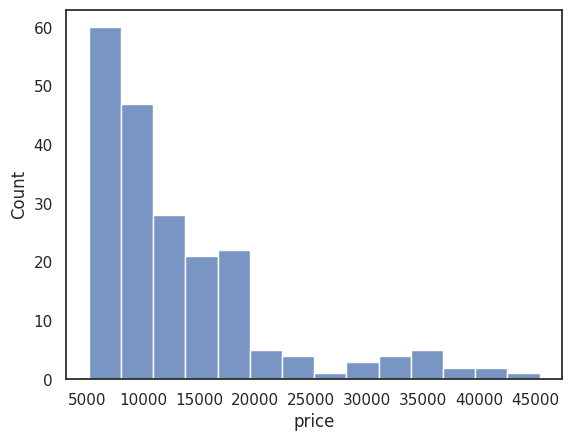

In [ ]:
sns.histplot(df.price)

<Axes: >

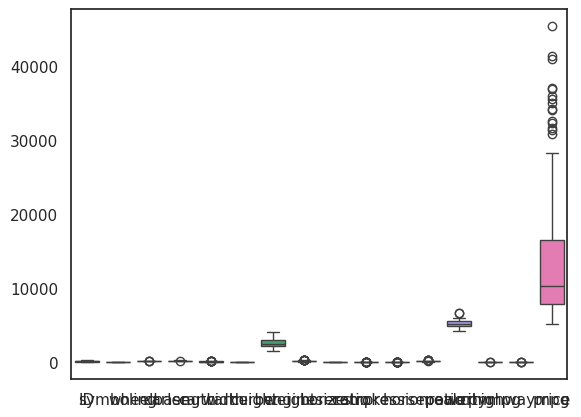

In [ ]:
sns.boxplot(df)

<Axes: >

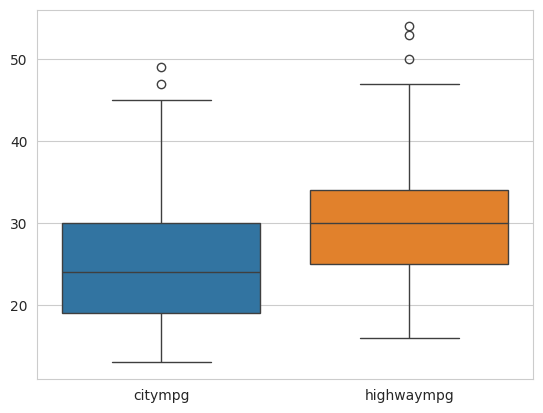

In [ ]:
sns.boxplot(df[['citympg', 'highwaympg']])

In [ ]:
df.columns

Index(['ID', 'symboling', 'fueltypes', 'aspiration', 'doornumbers', 'carbody',
       'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       ...
       'name_volkswagen type 3', 'name_volvo 144ea', 'name_volvo 145e (sw)',
       'name_volvo 244dl', 'name_volvo 245', 'name_volvo 246',
       'name_volvo 264gl', 'name_volvo diesel', 'name_vw dasher',
       'name_vw rabbit'],
      dtype='object', length=171)

In [ ]:
features = ['enginesize', 'horsepower', 'curbweight', 'citympg', 'highwaympg'] + \
           [col for col in df.columns if col.startswith('name_')]
X = df[features]
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
# Standardize (fit on train, transform both train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

In [ ]:
Ir = LinearRegression()
Ir.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = Ir.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nIr Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")


Ir Evaluation Metrics:
Mean Squared Error (MSE): 26093077.63
Root Mean Squared Error (RMSE): 5108.14
R-squared (R2 Score): 0.67


In [ ]:
df.price.describe()

,price
count,205.000000
mean,13276.710571
std,7988.852332
min,5118.000000
25%,7788.000000
50%,10295.000000
75%,16503.000000
max,45400.000000


In [ ]:
features = ['enginesize', 'horsepower', 'curbweight', 'citympg', 'highwaympg', 'name']
X = df[features]
y = df['price']
encoder = ce.BinaryEncoder(cols=['name'])
X_encoded = encoder.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.1, random_state=42)



In [ ]:
# Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
Ir = LinearRegression()
Ir.fit(X_train_scaled, y_train)

# Predictions
y_pred = Ir.predict(X_test_scaled)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 6659307.282306861
RMSE: 2580.563365295815
R²: 0.916853067794152


In [ ]:
encoder = LabelEncoder()
df['fueltypes'] = encoder.fit_transform(df['fueltypes'])

In [ ]:
df['fueltypes'].value_counts()

,count
fueltypes,
1,185
0,20


In [ ]:
features = ['enginesize', 'horsepower', 'curbweight', 'citympg', 'highwaympg', 'fueltypes']
X = df[features]
y = df['price']
#encoder = ce.BinaryEncoder(cols=['name'])
#X_encoded = encoder.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.1, random_state=42)



In [ ]:
# Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
Ir = LinearRegression()
Ir.fit(X_train_scaled, y_train)

# Predictions
y_pred = Ir.predict(X_test_scaled)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 7621271.1482096
RMSE: 2760.6649829723274
R²: 0.9048421572066198


In [ ]:
#import pandas
import pandas as pd

# load dataset
pima = pd.read_csv("/content/diabetes.csv")

In [ ]:
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
pima.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
len(pima)

768

<Axes: xlabel='Insulin', ylabel='Count'>

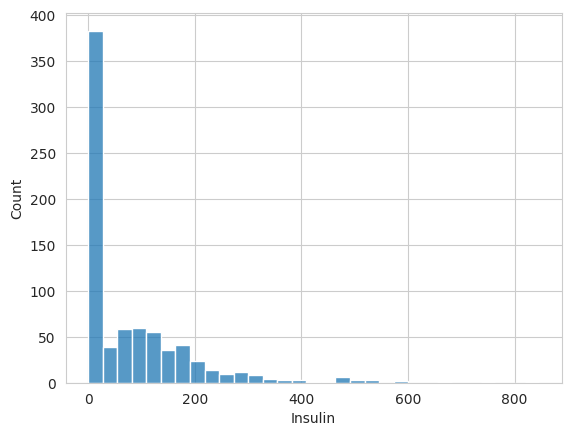

In [ ]:
sns.histplot(pima.Insulin)

In [ ]:
#split dataset in features and target variable
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age','BloodPressure','SkinThickness','DiabetesPedigreeFunction']
X = pima[feature_cols] # Features
y = pima.Outcome # Target variable

In [ ]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [ ]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
len(y_test)

192

Check accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6927


Check confusion metric

In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[104  21]
 [ 38  29]]


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.83      0.78       125
           1       0.58      0.43      0.50        67

    accuracy                           0.69       192
   macro avg       0.66      0.63      0.64       192
weighted avg       0.68      0.69      0.68       192



In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
#  Train the model
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  # apply scaling on testing data, without leaking training data

0.6927083333333334

In [ ]:
# import the metrics class
from sklearn import metrics
y_pred = pipe.predict(X_test)
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[105,  20],
       [ 39,  28]])

Text(0.5, 427.9555555555555, 'Predicted label')

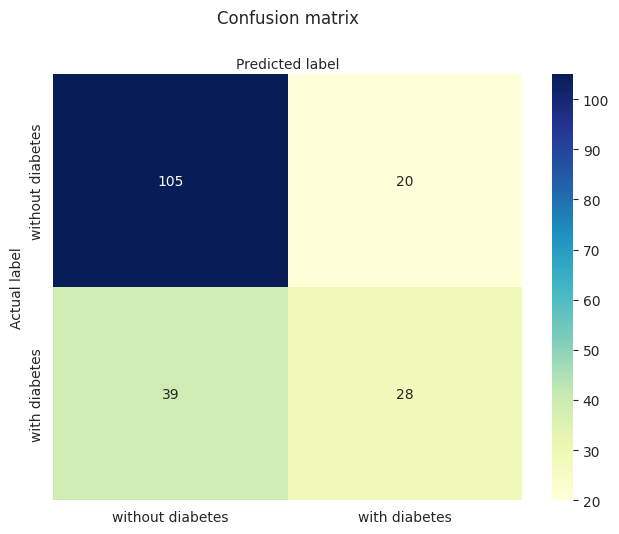

In [ ]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=['without diabetes', 'with diabetes'] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
# create heatmap
sns.heatmap(
    pd.DataFrame(cnf_matrix),
    annot=True,
    cmap="YlGnBu",
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names
)

ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')



In [ ]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.73      0.84      0.78       125
   with diabetes       0.58      0.42      0.49        67

        accuracy                           0.69       192
       macro avg       0.66      0.63      0.63       192
    weighted avg       0.68      0.69      0.68       192



In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures


# X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)
pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=False),
    LogisticRegression(max_iter=1000)
)

pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  # apply scaling on testing data, without leaking training data.

0.7447916666666666

In [ ]:
# import the metrics class
from sklearn import metrics
y_pred = pipe.predict(X_test)
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

NameError: name 'pipe' is not defined

Text(0.5, 427.9555555555555, 'Predicted label')

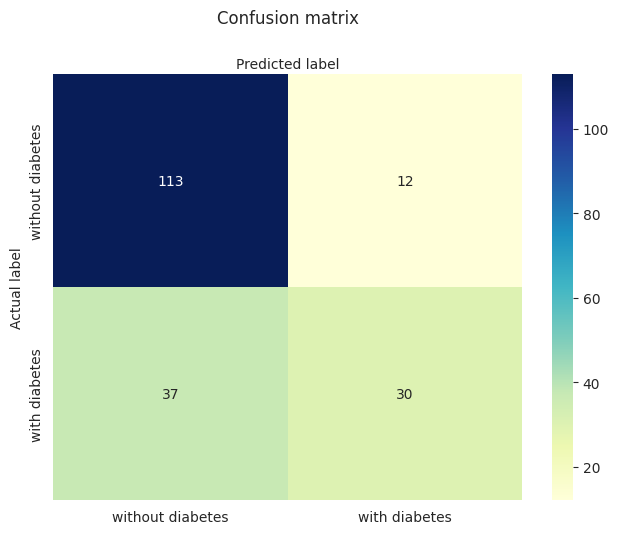

In [ ]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=['without diabetes', 'with diabetes'] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
# create heatmap
sns.heatmap(
    pd.DataFrame(cnf_matrix),
    annot=True,
    cmap="YlGnBu",
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names
)

ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

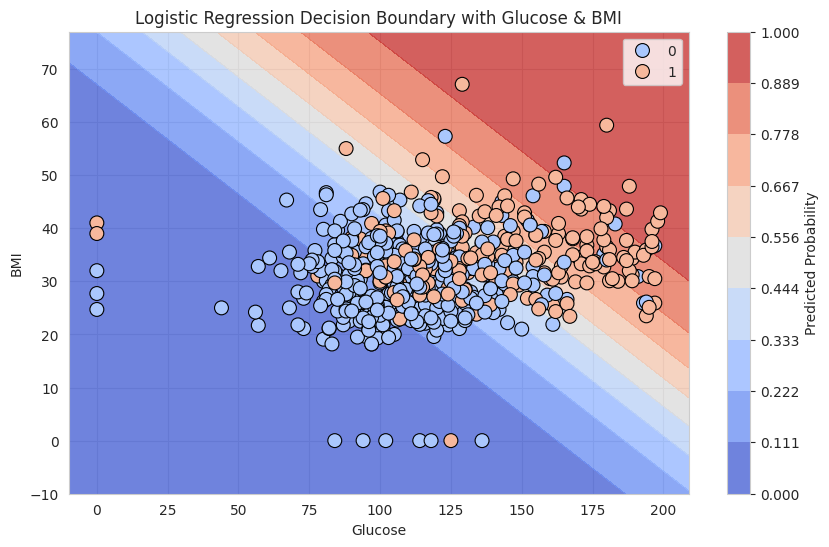

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select two features: Glucose and BMI, and the target (Outcome)
X = pima[['Glucose', 'BMI']].values
y = pima['Outcome'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Generate a mesh grid for visualization
x_min, x_max = X_train[:, 0].min() - 10, X_train[:, 0].max() + 10
y_min, y_max = X_train[:, 1].min() - 10, X_train[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the probabilities for the mesh grid
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]  # Probability of Outcome = 1
Z = Z.reshape(xx.shape)

# Plot the logistic regression decision boundary and the logistic function
plt.figure(figsize=(10, 6))

# Plot the decision boundary with predicted probabilities
contour = plt.contourf(xx, yy, Z, alpha=0.8, levels=np.linspace(0, 1, 10), cmap='coolwarm')

# Add a color bar to show the probability values
plt.colorbar(contour, label="Predicted Probability")

# Plot the original data points
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='coolwarm', edgecolor='k', s=100)

# Label the plot
plt.title("Logistic Regression Decision Boundary with Glucose & BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

# Show the plot
plt.show()





In [ ]:
pima.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


<Axes: xlabel='BloodPressure', ylabel='Age'>

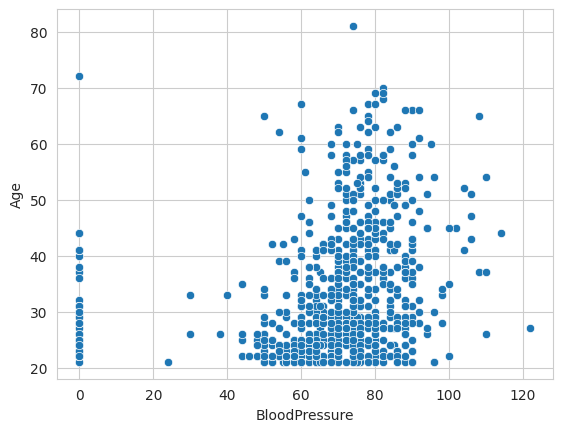

In [ ]:
sns.scatterplot(x=pima.BloodPressure, y=pima.Age)

<Axes: xlabel='BMI', ylabel='BloodPressure'>

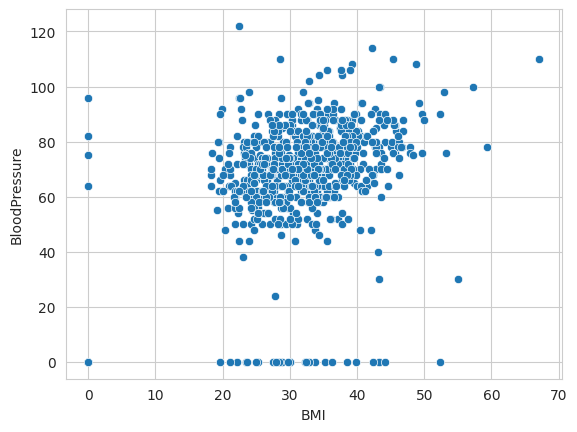

In [ ]:
sns.scatterplot(x=pima.BMI, y=pima.BloodPressure)

<Axes: xlabel='BloodPressure', ylabel='Outcome'>

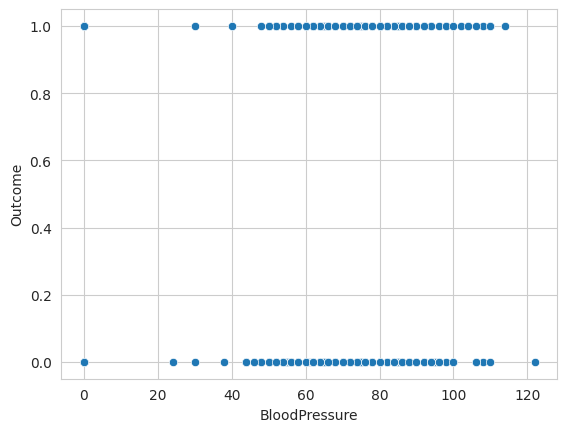

In [ ]:
sns.scatterplot(x=pima.BloodPressure, y=pima.Outcome)

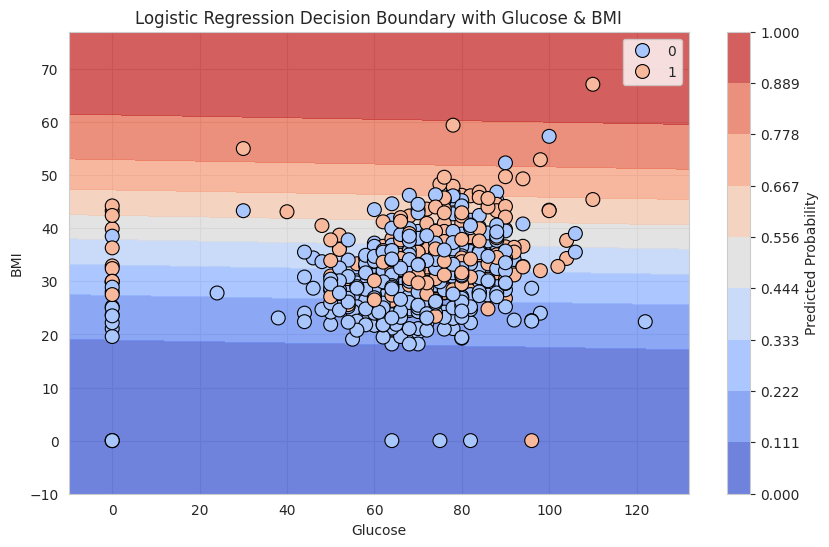

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
X = pima[['BloodPressure', 'BMI']].values
y = pima['Outcome'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Generate a mesh grid for visualization
x_min, x_max = X_train[:, 0].min() - 10, X_train[:, 0].max() + 10
y_min, y_max = X_train[:, 1].min() - 10, X_train[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the probabilities for the mesh grid
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]  # Probability of Outcome = 1
Z = Z.reshape(xx.shape)

# Plot the logistic regression decision boundary and the logistic function
plt.figure(figsize=(10, 6))

# Plot the decision boundary with predicted probabilities
contour = plt.contourf(xx, yy, Z, alpha=0.8, levels=np.linspace(0, 1, 10), cmap='coolwarm')

# Add a color bar to show the probability values
plt.colorbar(contour, label="Predicted Probability")

# Plot the original data points
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='coolwarm', edgecolor='k', s=100)

# Label the plot
plt.title("Logistic Regression Decision Boundary with Glucose & BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

# Show the plot
plt.show()